Original shape: (4803, 20)

After cleaning: (3762, 15)

Class balance:
success
1    2438
0    1324
Name: count, dtype: int64
success
1    0.64806
0    0.35194
Name: proportion, dtype: float64

Top genres used:
['Drama', 'Comedy', 'Thriller', 'Action', 'Adventure']
Number of features: 10

Test Results
Accuracy : 0.7503
Precision: 0.7669
Recall   : 0.8832
F1 Score : 0.821
ROC AUC  : 0.805

Confusion Matrix:
[[134 131]
 [ 57 431]]

Confusion Matrix Breakdown:
True Negatives : 134
False Positives: 131
False Negatives: 57
True Positives : 431

Classification Report:
              precision    recall  f1-score   support

           0     0.7016    0.5057    0.5877       265
           1     0.7669    0.8832    0.8210       488

    accuracy                         0.7503       753
   macro avg     0.7342    0.6944    0.7043       753
weighted avg     0.7439    0.7503    0.7389       753


Logistic Regression Coefficients:
        feature  coefficient
 log_popularity     1.570220
        runt

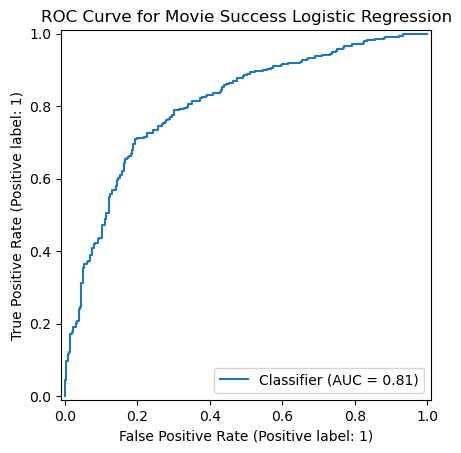


Top Predicted Successful Movies with Actual Outcomes:
                                                  title  \
95                                         Interstellar   
546                                             Minions   
788                                            Deadpool   
94                              Guardians of the Galaxy   
127                                  Mad Max: Fury Road   
28                                       Jurassic World   
199   Pirates of the Caribbean: The Curse of the Bla...   
3337                                      The Godfather   
329       The Lord of the Rings: The Return of the King   
262   The Lord of the Rings: The Fellowship of the Ring   

      predicted_probability  success  
95                 0.998860        1  
546                0.998784        1  
788                0.997741        1  
94                 0.997306        1  
127                0.995979        1  
28                 0.995954        1  
199                0.9

In [8]:
"""
Predicting Movie Success - Standard Logistic Regression

Shawn Lokshin, Fedor Bentsa, Borys Kocherev
"""

import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

# Load data

df = pd.read_csv("tmdb_5000_movies.csv")
print("Original shape:", df.shape)


# Feature preprocessing

df = df[[
    "title",
    "budget",
    "revenue",
    "runtime",
    "popularity",
    "genres",
    "release_date",
    "original_language",
    "vote_average",
    "vote_count"
]].copy()

df = df[
    df["budget"].notna() &
    df["revenue"].notna() &
    df["runtime"].notna() &
    df["popularity"].notna() &
    df["genres"].notna() &
    df["release_date"].notna() &
    (df["budget"] > 0) &
    (df["revenue"] >= 0) &
    (df["runtime"] > 0) &
    (df["popularity"] > 0)
].copy()

df["success"] = (df["revenue"] > df["budget"]).astype(int)
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df = df.dropna(subset=["release_date"]).copy()

df["release_month"] = df["release_date"].dt.month
df["is_english"] = (df["original_language"] == "en").astype(int)
df["log_budget"] = np.log(df["budget"])
df["log_popularity"] = np.log(df["popularity"] + 1)

print("\nAfter cleaning:", df.shape)
print("\nClass balance:")
print(df["success"].value_counts())
print(df["success"].value_counts(normalize=True))


# Extract top 5 genre dummies

def extract_genres(x):
    try:
        items = ast.literal_eval(x)
        return [item["name"] for item in items]
    except Exception:
        return []

df["genres_list"] = df["genres"].apply(extract_genres)

all_genres = [g for row in df["genres_list"] for g in row]
top_genres = pd.Series(all_genres).value_counts().head(5).index.tolist()

print("\nTop genres used:")
print(top_genres)

for g in top_genres:
    clean_name = "genre_" + "".join(ch.lower() if ch.isalnum() else "_" for ch in g)
    df[clean_name] = df["genres_list"].apply(lambda x: int(g in x))

genre_cols = ["genre_" + "".join(ch.lower() if ch.isalnum() else "_" for ch in g) for g in top_genres]


# Build dataset for the model 

feature_cols = [
    "log_budget",
    "log_popularity",
    "runtime",
    "release_month",
    "is_english"
] + genre_cols

X = df[feature_cols].copy()
y = df["success"].copy()

print("Number of features:", len(feature_cols))


# 80/20 Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=4420,
    stratify=y
)


# Standardize numeric columns only

numeric_cols = ["log_budget", "log_popularity", "runtime", "release_month"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])


# Fit standard logistic regression

log_reg = LogisticRegression(
    max_iter=5000,
    solver="lbfgs"
)

log_reg.fit(X_train_scaled, y_train)


# Evaluate model

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("\nTest Results")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1 Score :", round(f1, 4))
print("ROC AUC  :", round(auc, 4))


# Confusion Matrix

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Breakdown:")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


# Show coefficients for interpretation

coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nLogistic Regression Coefficients:")
print(coef_df.to_string(index=False))


# ROC curve

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve for Movie Success Logistic Regression")
plt.show()


# Full-dataset prediction review

X_all_scaled = X.copy()
X_all_scaled[numeric_cols] = scaler.transform(X[numeric_cols])

df["predicted_probability"] = log_reg.predict_proba(X_all_scaled)[:, 1]

top_movies = df.sort_values("predicted_probability", ascending=False)
print("\nTop Predicted Successful Movies with Actual Outcomes:")
print(top_movies[[
    "title",
    "predicted_probability",
    "success"
]].head(10))

print("\nFalse Positives (looked like hits but failed):")
false_positives = df[
    (df["predicted_probability"] > 0.8) &
    (df["success"] == 0)
]
print(false_positives[[
    "title",
    "predicted_probability",
    "budget",
    "revenue"
]].head(10))

print("\nFalse Negatives (unexpected hits):")
false_negatives = df[
    (df["predicted_probability"] < 0.2) &
    (df["success"] == 1)
]
print(false_negatives[[
    "title",
    "predicted_probability",
    "budget",
    "revenue"
]].head(10))

print("\nTrue Negatives (correctly predicted failures):")
true_negatives = df[
    (df["predicted_probability"] < 0.2) &
    (df["success"] == 0)
]
print(true_negatives[[
    "title",
    "predicted_probability",
    "budget",
    "revenue"
]].head(10))